# LiDAR Data Prep

This notebook prepares **LiDAR (ASO) snow water equivalent (SWE)** data for ST-GNN evaluation: it loads ASO 50 m SWE rasters (NSIDC), defines the Pacific Northwest extent, fetches HUC12/HUC8 geometries from Earth Engine and S3, masks rasters to HUC12 polygons, and aggregates mean SWE per HUC12 per date. Output: `lidar_swe_huc12_aggregated.csv` for use in model evaluation.

## Imports

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show
import geopandas as gpd
import boto3
import json
import ee
from shapely.geometry import box

from snowML.datapipe.utils import data_utils as du
from snowML.datapipe.utils import get_geos as gg

Define local paths to ASO 50 m SWE GeoTIFFs (e.g. NSIDC downloads) and get combined extent for the region.

In [ ]:
s3 = boto3.client("s3")
bucket = "snowml-lidar"

In [ ]:
# Your raster files
raster_files = [
    "ASO_50M_SWE_USWAOL_20160208.tif",
    "ASO_50M_SWE_USWAOL_20160329.tif"
]

all_boxes = []

for key in raster_files:
    # Read from S3
    obj = s3.get_object(Bucket=bucket, Key=key)
    tif_bytes = obj["Body"].read()

    # Open with rasterio in-memory
    with MemoryFile(tif_bytes) as memfile:
        with memfile.open() as src:
            bounds = src.bounds
            crs = src.crs

            print(f"\nFile: {key}")
            print("CRS:", crs)
            print("Resolution:", src.res)
            print("Bounds:")
            print("  Left:", bounds.left)
            print("  Right:", bounds.right)
            print("  Top:", bounds.top)
            print("  Bottom:", bounds.bottom)

            bbox = box(bounds.left, bounds.bottom, bounds.right, bounds.top)
            all_boxes.append(bbox)


# Combine extents
combined_extent = all_boxes[0]
for b in all_boxes[1:]:
    combined_extent = combined_extent.union(b)

print("\nCombined extent of both rasters:")
print(combined_extent)


File: nsidc_downloads/ASO_50M_SWE_USWAOL_20160208.tif
CRS: EPSG:32610
Resolution: (50.000101089, 50.000101089)
Bounds:
  Left: 411771.0
  Right: 490321.158810819
  Top: 5326407.0
  Bottom: 5260606.866966876

File: nsidc_downloads/ASO_50M_SWE_USWAOL_20160329.tif
CRS: EPSG:32610
Resolution: (50.000101089, 50.000101089)
Bounds:
  Left: 411771.0
  Right: 490321.158810819
  Top: 5326407.0
  Bottom: 5260606.866966876

Combined extent of both rasters:
POLYGON ((490321.158810819 5260606.866966876, 411771 5260606.866966876, 411771 5326407, 490321.158810819 5326407, 490321.158810819 5260606.866966876))


Plot the first raster as a quick visual check (extent and values).

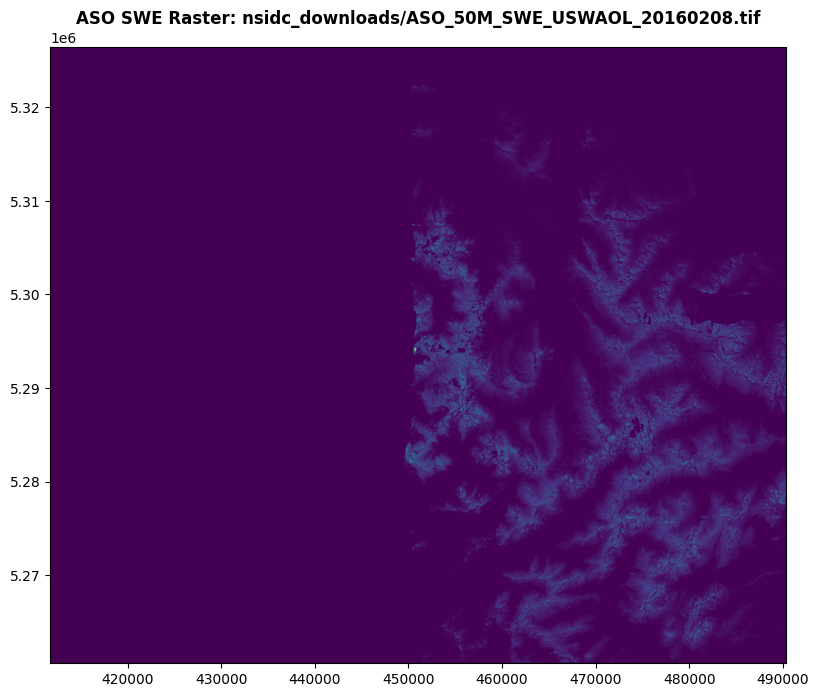

In [9]:
import matplotlib.pyplot as plt

# Plot the first tif file as an example
with rasterio.open(raster_files[0]) as src:
    fig, ax = plt.subplots(figsize=(10, 8))
    rasterio.plot.show(src, ax=ax, title="ASO SWE Raster: " + raster_files[0])
    plt.show()

**Helper: get_geo_jsons.** Load GeoJSON geometries for a list of HUC IDs from S3 (`snowml-shape`), by HUC level (e.g. 8 or 12).

In [22]:
def get_geo_jsons(huc_ids, huc_level, bucket_nm="snowml-shape"):
    gdf = []
    temp = None
    for huc_id in huc_ids:
        f_out = f"Huc{huc_level}_in_{huc_id}.geojson"
        if du.isin_s3(bucket_nm, f_out):
            print(f"Getting geos from s3 bucket for {huc_id}")
            temp = du.s3_to_gdf(bucket_nm, f_out)
        else:
            try:
                print(f"Getting geos from google earth for {huc_id}")
                temp = gg.get_geos(huc_id, huc_level, s3_save=False, bucket_nm=bucket_nm)
            except Exception as e:
                # log the error and continue; store None for this huc_id
                print(f"Error getting geos for {huc_id}: {e}")
        gdf.append(temp)
        print(f"Found {len(temp)} HUC {huc_level}s in {huc_id}")
    return gpd.GeoDataFrame(pd.concat(gdf, ignore_index=True))

Set ASO bounds (WGS84) for the Pacific Northwest and optionally plot on a basemap.

In [11]:
# Plot ASO bounds on US map
# ASO 50m SWE bounding box from NSIDC (WEST, SOUTH, EAST, NORTH) - Pacific Northwest
aso_bounds = list(combined_extent.bounds)
# Ensure coordinates are in WGS84 (EPSG:4326) before plotting the box.
# If combined_extent is not already in EPSG:4326, reproject.
if hasattr(combined_extent, 'crs'):
    # If combined_extent is a GeoSeries/GeoDataFrame with CRS
    if combined_extent.crs != "EPSG:4326":
        combined_extent = combined_extent.to_crs("EPSG:4326")
    aso_bounds = list(combined_extent.total_bounds)
else:
    # Assume it's a plain geometry (shapely)
    try:
        from pyproj import CRS, Transformer
        # Try to reproject if crs is defined elsewhere
        crs_init = None
        if 'crs' in locals():
            crs_init = crs
        elif 'extent_gdf' in locals():
            crs_init = extent_gdf.crs
        if crs_init is not None and crs_init != "EPSG:4326":
            src_crs = CRS.from_user_input(crs_init)
            dst_crs = CRS.from_epsg(4326)
            transformer = Transformer.from_crs(src_crs, dst_crs, always_xy=True)
            x_min, y_min, x_max, y_max = combined_extent.bounds
            x0, y0 = transformer.transform(x_min, y_min)
            x1, y1 = transformer.transform(x_max, y_max)
            aso_bounds = [min(x0, x1), min(y0, y1), max(x0, x1), max(y0, y1)]
        else:
            aso_bounds = list(combined_extent.bounds)
    except Exception as e:
        # fallback: assume already WGS84, just warn
        print("Warning: Could not check/reproject the extent CRS. Assuming EPSG:4326.", e)
        aso_bounds = list(combined_extent.bounds)

# from shapely.geometry import box
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature

# fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={"projection": ccrs.PlateCarree()})

# # US extent
# ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())

# # Add map features
# ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.5)
# ax.add_feature(cfeature.OCEAN, facecolor="lightblue", alpha=0.5)
# ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor="gray")
# ax.add_feature(cfeature.BORDERS, linewidth=1, edgecolor="black")
# ax.coastlines(resolution="110m", linewidth=0.8)

# # ASO bounds rectangle (WGS84)
# aso_box = box(aso_bounds[0], aso_bounds[1], aso_bounds[2], aso_bounds[3])
# gdf_aso = gpd.GeoDataFrame(
#     {"name": ["ASO 50m SWE"]},
#     geometry=[aso_box],
#     crs="EPSG:4326"
# )
# gdf_aso.plot(ax=ax, facecolor="coral", edgecolor="darkred", linewidth=2, alpha=0.6)

# ax.set_title("ASO 50m SWE Bounds on US Map (Pacific Northwest)", fontsize=14)
# ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
# plt.tight_layout()
# plt.show()

Display the ASO bounding box coordinates (WEST, SOUTH, EAST, NORTH).

In [12]:
aso_bounds

[-124.17134026456013, 47.49291174815164, -123.12997940574073, 48.0908583209779]

Read raster bounds and CRS; use **pyproj.Transformer** to convert to WGS84 if needed for Earth Engine / HUC intersection.

In [13]:
import rasterio
from pyproj import Transformer

tif_path = "nsidc_downloads/ASO_50M_SWE_USWAOL_20160208.tif"

with rasterio.open(tif_path) as src:
    bounds = src.bounds
    src_crs = src.crs

# transformer
transformer = Transformer.from_crs(src_crs, "EPSG:4326", always_xy=True)

# transform corners
lon_min, lat_min = transformer.transform(bounds.left, bounds.bottom)
lon_max, lat_max = transformer.transform(bounds.right, bounds.top)

aso_bounds_wgs84 = [lon_min, lat_min, lon_max, lat_max]

print("ASO bounds (EPSG:4326):")
print(aso_bounds_wgs84)

ASO bounds (EPSG:4326):
[-124.17134026456013, 47.49291174815164, -123.12997940574073, 48.0908583209779]


Initialize **Google Earth Engine** and define the bounding box; used to query HUC12 features that intersect the ASO extent.

In [25]:
import ee

# Initialize the Earth Engine library (make sure authentication is handled earlier in your code)
# ee.Authenticate()
ee.Initialize()

# Define the bounding box
# bbox = ee.Geometry.Rectangle([
#     -124.17134026456013, 47.49291174815164,
#     -123.12997940574073, 48.0908583209779
# ])

bbox = ee.Geometry.Rectangle(aso_bounds_wgs84)

# Load the HUC12 feature collection
huc12 = ee.FeatureCollection("USGS/WBD/2017/HUC12")

# Filter the collection to features within the bounding box
selected = huc12.filterBounds(bbox)

# If you have geemap installed and want to visualize:
# import geemap
# Map = geemap.Map()
# Map.addLayer(selected, {}, "Selected HUC12")
# Map

# Print information about the selected features
print(selected.getInfo())

{'type': 'FeatureCollection', 'columns': {'areaacres': 'String', 'areasqkm': 'String', 'gnis_id': 'String', 'huc12': 'String', 'humod': 'String', 'hutype': 'String', 'loaddate': 'String', 'metasource': 'String', 'name': 'String', 'noncontr00': 'String', 'noncontrib': 'String', 'shape_area': 'String', 'shape_leng': 'String', 'sourcedata': 'String', 'sourcefeat': 'String', 'sourceorig': 'String', 'states': 'String', 'system:index': 'String', 'tnmid': 'String', 'tohuc': 'String'}, 'version': 1566842822671711, 'id': 'USGS/WBD/2017/HUC12', 'properties': {'date_range': [1492819200000, 1492905600000], 'period': 0, 'thumb': 'https://mw1.google.com/ges/dd/images/USGS_WBD_thumb.png', 'description': '<p>The Watershed Boundary Dataset (WBD) is a comprehensive\naggregated collection of hydrologic unit (HU) data consistent\nwith the national criteria for delineation and resolution. It\ndefines the areal extent of surface water drainage to a point\nexcept in coastal or lake front areas where there co

Build a Shapely box from ASO bounds and select HUC12s that are (fully) inside the bbox for masking.

In [26]:
import shapely.geometry

# Get the shapely geometry for the bbox (EPSG:4326)
bbox_geom = shapely.geometry.box(*aso_bounds_wgs84)

# Fetch all HUC12 features that intersect the bbox
info = selected.getInfo()
features = info.get("features", [])

# Filter to HUC12s that are fully contained within the bbox
huc12_completely_inside = []
for f in features:
    geom = f.get("geometry")
    if geom is not None:
        shapely_geom = shapely.geometry.shape(geom)
        if shapely_geom.within(bbox_geom):
            huc12_id = f["properties"].get("huc12") or f["properties"].get("huc_id") or f["properties"].get("HUC12")
            huc12_completely_inside.append(huc12_id)

print("HUC12s completely inside bbox:")
print(huc12_completely_inside)
print(len(huc12_completely_inside))

HUC12s completely inside bbox:
['171001010501', '171001010601', '171001010602', '171001010701', '171001010702', '171001010703', '171001010704', '171001010705', '171001020102', '171001020101', '171001020201', '171001020203', '171001020202', '171001020206', '171001020205', '171001020204', '171001020207', '171001020402', '171001020401', '171001020404', '171001020405', '171001020406', '171100180501', '171100180502', '171100200304', '171100200303', '171100200502', '171100200501', '171100200504', '171100200503', '171100200505', '171100200506', '171100200507', '171100200508', '171100200509', '171100200510', '171100200511', '171100200512', '171100210201']
39


Create a DataFrame of HUC12 IDs inside the extent; add **huc8** and **huc6** from the first 8 and 6 digits.

In [27]:

# Create DataFrame from the list of HUC12 IDs
df_huc12 = pd.DataFrame({'huc12': huc12_completely_inside})

# Add columns for HUC8 (first 8 digits) and HUC6 (first 6 digits)
df_huc12['huc8'] = df_huc12['huc12'].apply(lambda x: str(x)[:8])
df_huc12['huc6'] = df_huc12['huc12'].apply(lambda x: str(x)[:6])

df_huc12

,huc12,huc8,huc6
0,171001010501,17100101,171001
1,171001010601,17100101,171001
2,171001010602,17100101,171001
3,171001010701,17100101,171001
4,171001010702,17100101,171001
5,171001010703,17100101,171001
6,171001010704,17100101,171001
7,171001010705,17100101,171001
8,171001020102,17100102,171001
9,171001020101,17100102,171001


Get unique HUC8s, then load HUC12 GeoJSONs for those basins via **get_geo_jsons** (for raster masking).

In [28]:
huc8s = df_huc12['huc8'].unique()
huc8_list = list(huc8s)
print(huc8_list)
gdf_new = get_geo_jsons(huc8_list, "12")
len(gdf_new)

['17100101', '17100102', '17110018', '17110020', '17110021']
Getting geos from google earth for 17100101
Found 39 HUC 12s in 17100101
Getting geos from google earth for 17100102
Found 37 HUC 12s in 17100102
Getting geos from google earth for 17110018
Found 27 HUC 12s in 17110018
Getting geos from google earth for 17110020
Found 39 HUC 12s in 17110020
Getting geos from google earth for 17110021
Found 59 HUC 12s in 17110021


201

Inspect the loaded GeoDataFrame columns (geometry and attributes).

In [29]:
gdf_new.columns


Index(['huc_id', 'geometry'], dtype='object')

## Aggregate LiDAR SWE by HUC12

Loop over rasters and HUC12 polygons: **rasterio.mask** to clip each TIF to each polygon, compute mean SWE per HUC12 per date, and build **df_lidar_huc12** (huc_id, date, mean_lidar_swe).

In [40]:
import os
import re
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask

# -----------------------------
# INPUTS
# -----------------------------
lidar_files = [
    "nsidc_downloads/ASO_50M_SWE_USWAOL_20160208.tif",
    "nsidc_downloads/ASO_50M_SWE_USWAOL_20160329.tif"
]

# your full HUC12 geodataframe
# must contain geometry and huc12 column
# example:
# huc12_gdf = gpd.read_file(...)
huc_id_col = "huc_id"   # change if your column is named HUC12
output_csv = "lidar_swe_huc12_aggregated.csv"

# your list
# huc12_completely_inside = [...]

# -----------------------------
# FILTER HUC12s
# -----------------------------
huc_gdf_sub = gdf_new[gdf_new[huc_id_col].isin(huc12_completely_inside)].copy()

if huc_gdf_sub.empty:
    raise ValueError("No matching HUC12s found in gdf.")

rows = []

for tif_path in lidar_files:
    # extract date from filename like 20160208
    m = re.search(r"(\d{8})\.tif$", os.path.basename(tif_path))
    s = m.group(1) if m else None
    lidar_date = f"{s[:4]}-{s[4:6]}-{s[6:8]}"  # e.g. 2016-02-08

    with rasterio.open(tif_path) as src:
        raster_crs = src.crs
        nodata = src.nodata
        transform = src.transform
        pixel_area_m2 = abs(transform.a * transform.e)  # usually 50m * 50m = 2500 m²

        # match CRS
        hucs_proj = huc_gdf_sub.to_crs(raster_crs)

        for _, row in hucs_proj.iterrows():
            huc_id = row[huc_id_col]
            geom = [row.geometry]

            try:
                out_image, out_transform = mask(src, geom, crop=True)
                data = out_image[0]   # first band

                # remove nodata / masked values
                if nodata is not None:
                    valid = data[data != nodata]
                else:
                    valid = data

                valid = valid[np.isfinite(valid)]

                # optional: remove negative SWE if your product should not include them
                valid = valid[valid >= 0]

                if len(valid) == 0:
                    rows.append({
                        "huc_id": huc_id,
                        "date": lidar_date,
                        "mean_lidar_swe": np.nan,
                    })
                    continue

                rows.append({
                    "huc_id": huc_id,
                    "date": lidar_date,
                    "mean_lidar_swe": float(np.mean(valid)),
                })

            except Exception as e:
                print(f"Error for HUC12 {huc_id} in {tif_path}: {e}")
                rows.append({
                    "huc_id": huc_id,
                    "date": lidar_date,
                    "mean_lidar_swe": np.nan,
                })

# -----------------------------
# SAVE OUTPUT
# -----------------------------
df_lidar_huc12 = pd.DataFrame(rows).sort_values(["date", "huc_id"]).reset_index(drop=True)
# df_lidar_huc12.to_csv(output_csv, index=False)

print(df_lidar_huc12.head())
# print(f"Saved: {output_csv}")

         huc_id        date  mean_lidar_swe
0  171001010501  2016-02-08        0.000000
1  171001010601  2016-02-08        0.000000
2  171001010602  2016-02-08        0.000000
3  171001010701  2016-02-08        0.277441
4  171001010702  2016-02-08        0.000000


Print min, max, mean, median of **mean_lidar_swe** across all HUC12–date pairs.

In [41]:
print(df_lidar_huc12['mean_lidar_swe'].min())
print(df_lidar_huc12['mean_lidar_swe'].max())
print(df_lidar_huc12['mean_lidar_swe'].mean())
print(df_lidar_huc12['mean_lidar_swe'].median())


0.0
0.91768878698349
0.25243427039225563
0.17543653398752213


Display the aggregated LiDAR SWE DataFrame (HUC12, date, mean_lidar_swe).

In [42]:
df_lidar_huc12

,huc_id,date,mean_lidar_swe
0,171001010501,2016-02-08,0.000000
1,171001010601,2016-02-08,0.000000
2,171001010602,2016-02-08,0.000000
3,171001010701,2016-02-08,0.277441
4,171001010702,2016-02-08,0.000000
...,...,...,...
73,171100200509,2016-03-29,0.401732
74,171100200510,2016-03-29,0.341493
75,171100200511,2016-03-29,0.100279
76,171100200512,2016-03-29,0.063228


Save **df_lidar_huc12** to **lidar_swe_huc12_aggregated.csv** for use in evaluation notebooks.

In [43]:
df_lidar_huc12.to_csv("lidar_swe_huc12_aggregated.csv", index=False)

*(Optional scratch cell.)*